# Sydney Sailors Notebook
# Intro to Jupyter and Exploratory Data Analysis (EDA)

- Author: [Sydney Sailors](https://github.com/sydsailors/)
- Repository: [datafun-04-notebooks](https://github.com/sydsailors/datafun-04-notebooks/)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-06

## Instructions

- Scan the headings first, to get an idea of the process and overall goal. 
- The provided content is a well-structured example that shows the process.
- Seek to understand the process and presentation of the work. 
- The goal is to be able to perform EDA **on any data you choose**. 

## Dataset Information

- Dataset: Diamonds
- Description: Diamond prices and attributes such as carat, cut, color, and clarity.
- Source: Original diamonds dataset popularized by ggplot2  
- Access: Provided via Seaborn's built-in datasets  
- Citation: selva86. (n.d.). diamonds.csv [Data set]. GitHub repository.

This is a Markdown cell.

## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes it clear what must be installed

This is a Markdown cell.

In [39]:
# This is a Python cell.


# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

import logging  # for type hinting only
from typing import Any, Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Type hint for Axes object (basic plot type returned by Seaborn)
# A seaborn plot is a set of axes. Set title, labels, etc. on the axes.
# A figure can contain multiple axes (plots)
# from matplotlib.figure import Figure

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("EDA-NB", level="DEBUG")
log_header(LOG, "EDA-NB")

# === Section 1c. Global Constants and Configuration ===

# CUSTOM: These are dataset-specific constants
# used in multiple places in the code.
# Inspect or explore the dataset to determine columns needed for analysis.

# CUSTOM: Data set name
DATASET_NAME: Final[str] = "diamonds"

# CUSTOM: Grouping column (chose one categorical/non-numeric variable)
GROUP_COL: Final[str] = "cut"

# CUSTOM: Numeric columns to analyze (chose 4-5 numeric variables)
SELECTED_NUMERIC_COLS: Final[list[str]] = [
    "carat",
    "depth",
    "table",
    "price",
]

# === Section 1d. Pandas Configuration for Display ===

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports complete.")

2026-06-03 13:38:58 | INFO | EDA-NB | === RUN START ===
2026-06-03 13:38:58 | INFO | EDA-NB | project=EDA-NB
2026-06-03 13:38:58 | INFO | EDA-NB | repo_dir=datafun-04-notebooks
2026-06-03 13:38:58 | INFO | EDA-NB | python=3.14.5
2026-06-03 13:38:58 | INFO | EDA-NB | os=Darwin 20.6.0
2026-06-03 13:38:58 | INFO | EDA-NB | shell=zsh
2026-06-03 13:38:58 | INFO | EDA-NB | cwd=notebooks
2026-06-03 13:38:58 | INFO | EDA-NB | github_actions=False
2026-06-03 13:38:58 | INFO | EDA-NB | Imports complete.


## Section 2. Load the Data

This is a Markdown cell.

WHY: Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable

This is a Markdown cell.

In [40]:
# Python cell

# Load a dataset into a DataFrame.

# Seaborn provides clean built-in datasets for practice.
# Other projects may load from CSV, JSON, or a database.

# Load the penguins dataset from Seaborn
# Into a pandas DataFrame (2D table)
LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

2026-06-03 13:38:58 | INFO | EDA-NB | Loading dataset: diamonds
2026-06-03 13:38:59 | INFO | EDA-NB | Loaded: 53940 rows, 10 columns


## Section 3. Inspect Data Shape and Structure

WHY: Always start by understanding what columns exist,
what types they are, and how large the dataset is.

- How many rows and columns are there?
- What types of data are present?
- Are there obvious missing values?

This step determines challenges we might have downstream (later).

This is a Markdown cell.

In [41]:
# Section 3 Python cell

# Preview the first few rows
# WHY: display() renders the DataFrame as a formatted table in the notebook.
#      A naked expression like df.head() only renders if it is the LAST line in a cell.
LOG.info("Previewing first few rows of the dataset")
display(df.head())

2026-06-03 13:38:59 | INFO | EDA-NB | Previewing first few rows of the dataset


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [42]:
# Section 3 Python cell

LOG.info("Column names")
print(list(df.columns))

2026-06-03 13:38:59 | INFO | EDA-NB | Column names


['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


In [43]:
# Section 3 Python cell

# DataFrame info (types and non-null counts)
# WHY: df.info() prints directly - no display() needed.
LOG.info("DataFrame info (types and non-null counts)")
df.info()

2026-06-03 13:38:59 | INFO | EDA-NB | DataFrame info (types and non-null counts)


<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [44]:
# Section 3 Python cell

# Get shape - number of rows and columns
# It has two parts so the return value is a tuple of (num_rows, num_columns)
shape: tuple[int, int] = df.shape

# To get each value, we can unpack the tuple into two variables
# This is a common Python idiom for working with tuples.
# Or we could just use shape[0] and shape[1] directly without unpacking.

num_rows, num_cols = shape

LOG.info(f"Dataset shape: {num_rows} rows, {num_cols} columns")

2026-06-03 13:38:59 | INFO | EDA-NB | Dataset shape: 53940 rows, 10 columns


## Section 4. Create Data Dictionary and Check Data Quality

WHY: A data dictionary helps with understanding the structure and quality of the data.

WHY: Missing data is normal. We need to find out how much and where.

Missing data affects:

- Visualizations
- Summary statistics
- Machine learning models

LOOK FOR: 

- Columns with many missing values
- Patterns (entire rows missing multiple fields)

This is a Markdown cell.


In [45]:
# Section 4 Python cell

LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-03 13:38:59 | INFO | EDA-NB | Building starter data dictionary
2026-06-03 13:38:59 | DEBUG | EDA-NB | 
    column     dtype  missing_count  missing_pct
0    carat   float64              0          0.0
1      cut  category              0          0.0
2    color  category              0          0.0
3  clarity  category              0          0.0
4    depth   float64              0          0.0
5    table   float64              0          0.0
6    price     int64              0          0.0
7        x   float64              0          0.0
8        y   float64              0          0.0
9        z   float64              0          0.0


In [46]:
# Section 4 Python cell

LOG.info("Missing values per column:")
LOG.info(df.isnull().sum())

LOG.info("Checking missing values per column")
LOG.debug(f"\n{df.isna().sum().sort_values(ascending=False)}")

dup_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {dup_count}")

LOG.info("Call describe() for numeric columns")
LOG.debug(f"\n{df[SELECTED_NUMERIC_COLS].describe()}\n")

2026-06-03 13:38:59 | INFO | EDA-NB | Missing values per column:
2026-06-03 13:38:59 | INFO | EDA-NB | carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
2026-06-03 13:38:59 | INFO | EDA-NB | Checking missing values per column
2026-06-03 13:38:59 | DEBUG | EDA-NB | 
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
2026-06-03 13:38:59 | INFO | EDA-NB | Duplicate rows detected: 146
2026-06-03 13:38:59 | INFO | EDA-NB | Call describe() for numeric columns
2026-06-03 13:38:59 | DEBUG | EDA-NB | 
              carat         depth         table         price
count  53940.000000  53940.000000  53940.000000  53940.000000
mean       0.797940     61.749405     57.457184   3932.799722
std        0.474011      1.432621      2.234491   3989.439738
min        0.200000     43.000000     43.000000    326.000000
25%    

## Section 5. Create Clean View for EDA

Create a cleaned view for EDA.

Strategy:
  - Keep the original DataFrame unchanged
  - Drop rows missing key numeric fields and grouping field

WHY: EDA often focuses on a "clean" subset of the data.

This allows exploring patterns without being distracted by missing values.

This is a Markdown cell.

In [47]:
# Section 5 Python cell

# Build the list of columns we require to be non-missing
# This includes all the selected numeric columns plus the grouping column.
# SELECTED_NUMERIC_COLS is a list of strings,
# GROUP_COL is a single string
# Wrap GROUP_COL in a list - two lists can be combined with +
cols_required: list[str] = SELECTED_NUMERIC_COLS + [GROUP_COL]
LOG.debug(f"Columns required to be non-missing: {cols_required}")

# Drop a row if it is missing a value in ANY of the required columns
# dropna(subset=...) only looks at the specified columns, not the whole row
# .copy() creates a new DataFrame so we don't accidentally modify the original
df_clean: pd.DataFrame = df.dropna(subset=cols_required).copy()

# Compare sizes
count_original: int = df.shape[0]
count_clean: int = df_clean.shape[0]
count_dropped: int = count_original - count_clean

print(f"Original rows: {count_original}")
print(f"Clean rows:    {count_clean}")
print(f"Rows dropped:  {count_dropped}")

LOG.info(f"Original rows: {count_original}")
LOG.info(f"Clean rows:    {count_clean}")
LOG.info(f"Rows dropped:  {count_dropped}")

2026-06-03 13:38:59 | DEBUG | EDA-NB | Columns required to be non-missing: ['carat', 'depth', 'table', 'price', 'cut']
2026-06-03 13:38:59 | INFO | EDA-NB | Original rows: 53940
2026-06-03 13:38:59 | INFO | EDA-NB | Clean rows:    53940
2026-06-03 13:38:59 | INFO | EDA-NB | Rows dropped:  0


Original rows: 53940
Clean rows:    53940
Rows dropped:  0


## Section 6. Descriptive Statistics for Numeric Columns

WHY: Summary statistics offer a quick overview of numeric data:

- Central tendency (mean)
- Spread (std, min, max)
- Distribution shape (quartiles)

Grouping by a categorical variable (i.e., non-numeric column)
enables comparing statistics across categories

This is a Markdown cell.

In [58]:
# Section 6 Python cell

LOG.info("--------------- Manual statistics ---------------")

# Example: Calculate statistics for a specific column with numpy
mean_price = np.mean(df_clean["price"])
std_price = np.std(df_clean["price"])
min_price = np.min(df_clean["price"])
max_price = np.max(df_clean["price"])
# np.ptp() (peak to peak) is deprecated - use max - min instead
range_price = np.max(df_clean["price"]) - np.min(df_clean["price"])

# Log the example results with formatting
LOG.info("Price Statistics (using numpy):")
LOG.info(f"  Mean: ${mean_price:.2f}")
LOG.info(f"  Std Dev: ${std_price:.2f}")
LOG.info(f"  Min: ${min_price:.2f}")
LOG.info(f"  Max: ${max_price:.2f}")
LOG.info(f"  Range: ${range_price:.2f}")

2026-06-03 14:14:22 | INFO | EDA-NB | --------------- Manual statistics ---------------
2026-06-03 14:14:22 | INFO | EDA-NB | Price Statistics (using numpy):
2026-06-03 14:14:22 | INFO | EDA-NB |   Mean: $3932.80
2026-06-03 14:14:22 | INFO | EDA-NB |   Std Dev: $3989.40
2026-06-03 14:14:22 | INFO | EDA-NB |   Min: $326.00
2026-06-03 14:14:22 | INFO | EDA-NB |   Max: $18823.00
2026-06-03 14:14:22 | INFO | EDA-NB |   Range: $18497.00


In [49]:
# Section 6 Python cell

# LOG.info("--------------- Using pandas describe() method ---------------")

LOG.info("Computing overall descriptive statistics")

# Use describe() to get count, mean, std, min, 25%, 50%, 75%, max for numeric columns
# OPTION: Use .T to transpose the result so that columns become rows for easier reading in logs
stats_overall = df_clean[SELECTED_NUMERIC_COLS].describe().T
LOG.debug(f"\n{stats_overall}")

LOG.info("--------------- Using pandas groupby() and agg() ---------------")

LOG.info("Computing descriptive statistics by group")

# Step 1: Select only the numeric columns we want to summarize
df_numeric_subset: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# Step 2: Split the numeric subset into groups based on the grouping column
# groupby() returns a GroupBy object - not a DataFrame yet, just a plan to group
grouped = df_numeric_subset.groupby(df_clean[GROUP_COL])

# Step 3: For each group, compute multiple summary statistics at once
# agg() applies each function in the list to each numeric column
# The result has a multi-level column index: (numeric_column, statistic)
df_stats_by_group: pd.DataFrame = grouped.agg(["count", "mean", "std", "min", "max"])

LOG.debug(f"\n{df_stats_by_group}")

2026-06-03 13:38:59 | INFO | EDA-NB | Computing overall descriptive statistics
2026-06-03 13:38:59 | DEBUG | EDA-NB | 
         count         mean          std    min    25%     50%      75%       max
carat  53940.0     0.797940     0.474011    0.2    0.4     0.7     1.04      5.01
depth  53940.0    61.749405     1.432621   43.0   61.0    61.8    62.50     79.00
table  53940.0    57.457184     2.234491   43.0   56.0    57.0    59.00     95.00
price  53940.0  3932.799722  3989.439738  326.0  950.0  2401.0  5324.25  18823.00
2026-06-03 13:38:59 | INFO | EDA-NB | --------------- Using pandas groupby() and agg() ---------------
2026-06-03 13:38:59 | INFO | EDA-NB | Computing descriptive statistics by group
2026-06-03 13:38:59 | DEBUG | EDA-NB | 
           carat                                  depth                                   table                       \
           count      mean       std   min   max  count       mean       std   min   max  count       mean       std   
cut     

In [50]:
# Section 6 Python cell

LOG.info("--------------- Improving the output ---------------")

# Yuck: That's the multi-level column index in action.
# pandas lays out the result as (numeric_column, statistic) pairs
# side by side, wrapping when the terminal width runs out.
# With 4 numeric columns x 5 statistics = 20 columns total,
# it can only fit 2 numeric columns per line at 120 characters wide.
# Let's stack it so each numeric column's stats are grouped together
# vertically instead of horizontally.

stats_by_group_stacked: pd.DataFrame | pd.Series[Any] = df_stats_by_group.stack(level=0)
LOG.debug(f"\n{stats_by_group_stacked}")

2026-06-03 13:38:59 | INFO | EDA-NB | --------------- Improving the output ---------------
2026-06-03 13:38:59 | DEBUG | EDA-NB | 
                 count         mean          std     min       max
cut                                                               
Ideal     carat  21551     0.702837     0.432876    0.20      3.50
          depth  21551    61.709401     0.718539   43.00     66.70
          table  21551    55.951668     1.246423   43.00     63.00
          price  21551  3457.541970  3808.401172  326.00  18806.00
Premium   carat  13791     0.891955     0.515262    0.20      4.01
          depth  13791    61.264673     1.158815   58.00     63.00
          table  13791    58.746095     1.478573   51.00     62.00
          price  13791  4584.257704  4349.204961  326.00  18823.00
Very Good carat  12082     0.806381     0.459435    0.20      4.00
          depth  12082    61.818275     1.378631   56.80     64.90
          table  12082    57.956150     2.121448   44.00     66.0

## Section 7. Simple Correlations (Numeric Only)

Compute a simple numeric correlations to understand
relationships between numeric variables.

A correlation matrix is symmetric.
There are as many columns as numeric variables.
There are as many rows as numeric variables.
The diagonal values are always exactly 1.0.
since each variable perfectly correlates with itself.

WHY: Correlation tells us how numeric variables relate to each other.

- Values near 1 or -1 indicate strong relationships
- Values near 0 indicate weak or no linear relationship

This is a Markdown cell.

In [51]:
# Section 7 Python cell

LOG.info("Computing correlation matrix for numeric columns")

# Select only numeric columns
df_clean_numeric_cols: pd.DataFrame = df_clean.select_dtypes(include="number")

# calculate the correlation matrix using the df corr() method
correlation_matrix = df_clean_numeric_cols.corr()

LOG.info("\nCorrelation matrix:")
LOG.debug(f"\n{correlation_matrix}")

2026-06-03 13:38:59 | INFO | EDA-NB | Computing correlation matrix for numeric columns
2026-06-03 13:38:59 | INFO | EDA-NB | 
Correlation matrix:
2026-06-03 13:38:59 | DEBUG | EDA-NB | 
          carat     depth     table     price         x         y         z
carat  1.000000  0.028224  0.181618  0.921591  0.975094  0.951722  0.953387
depth  0.028224  1.000000 -0.295779 -0.010647 -0.025289 -0.029341  0.094924
table  0.181618 -0.295779  1.000000  0.127134  0.195344  0.183760  0.150929
price  0.921591 -0.010647  0.127134  1.000000  0.884435  0.865421  0.861249
x      0.975094 -0.025289  0.195344  0.884435  1.000000  0.974701  0.970772
y      0.951722 -0.029341  0.183760  0.865421  0.974701  1.000000  0.952006
z      0.953387  0.094924  0.150929  0.861249  0.970772  0.952006  1.000000


2026-06-03 13:38:59 | INFO | EDA-NB | ---------Visualize Correlation Matrix as a Heatmap---------------


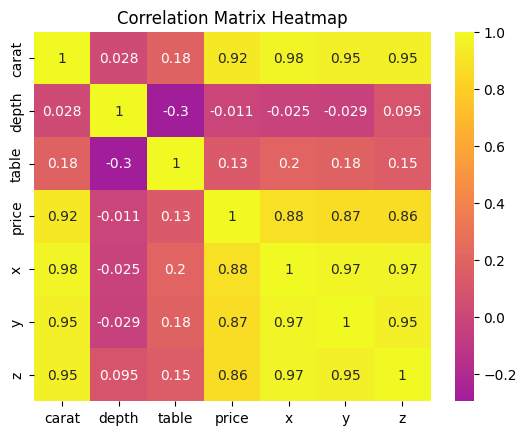

In [52]:
# Section 7 Python cell

LOG.info("---------Visualize Correlation Matrix as a Heatmap---------------")

# Set annotations to True to show correlation values
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="plasma",  # try coolwarm, viridis, plasma, or other colormaps
    center=0,
)
plt.title("Correlation Matrix Heatmap")
plt.show()

Interpretation:

 - Values close to 1 (bright yellow) = strong positive correlation (both increase together)
 - Values close to -1 (purple) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (pink) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that **x (length of diamond)** and **carat** show strong positive correlation (~0.98).

This is a Markdown cell.

## Section 8. Make Plots

Create simple, notebook-friendly plots.

WHY: Visualizations reveal patterns not obvious in tables.
CUSTOM: Charts will vary depending on the dataset
        and questions of interest.

Common charts include:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups

A scatter plot shows the relationship between two numeric variables.
In this example:
- Each dot is one data record shown as x vs y.
- Color (hue) provides a third dimension.

A box plot shows the distribution of one numeric variable across groups.
- The box shows the middle 50% of values.
- The line inside the box is the median.
- The whiskers show the range. Dots beyond the whiskers are outliers.


This is a Markdown cell.

2026-06-03 13:41:09 | INFO | EDA-NB | ---- Creating Scatter Plot to see Relationships ------
2026-06-03 13:41:09 | INFO | EDA-NB | ----   Use clean dataframe ---------------------------
2026-06-03 13:41:09 | INFO | EDA-NB | ----   Set x to carat --------------------------------
2026-06-03 13:41:09 | INFO | EDA-NB | ----   Set y to price --------------------------------
2026-06-03 13:41:09 | INFO | EDA-NB | ----   Set the hue (color mapping) to the group column --


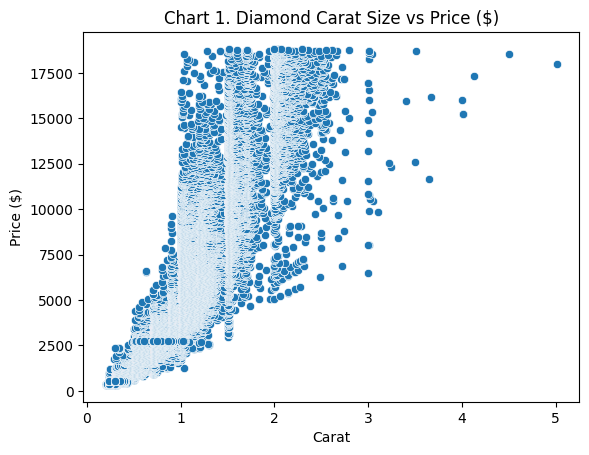

In [57]:
# Section 8 Python cell - use "Run All" so prior cells are executed first.

LOG.info("---- Creating Scatter Plot to see Relationships ------")
LOG.info("----   Use clean dataframe ---------------------------")
LOG.info("----   Set x to carat --------------------------------")
LOG.info("----   Set y to price --------------------------------")
LOG.info("----   Set the hue (color mapping) to the group column --")

# Scatter plot to see relationship
scatter_plt: Axes = sns.scatterplot(
    data=df_clean,
    x="carat",
    y="price",
)

# Set axis labels using the Matplotlib Axes methods set_xlabel() and set_ylabel()
scatter_plt.set_xlabel("Carat")
scatter_plt.set_ylabel("Price ($)")

# Set the title using the Matplotlib Axes set_title() method
scatter_plt.set_title("Chart 1. Diamond Carat Size vs Price ($)")

# IN NOTEBOOK: SHOW AS YOU GO
#      plt.show() displays the current chart and closes it
#      Call this before starting a new chart
#      or next chart will be drawn on top of this one
# IN SCRIPT: WAIT TO SHOW TILL THE END
#      Do not call plt.show() here - let figures accumulate
#      so all charts display together with sequential Figure numbers.
#      plt.show() is called once at the end of make_plots()
plt.show()

2026-06-03 13:39:00 | INFO | EDA-NB | ------- Creating another chart -------
2026-06-03 13:39:00 | INFO | EDA-NB | ------ Creating Box Plot to see Distribution: ---------
2026-06-03 13:39:00 | INFO | EDA-NB | ------   Use clean dataframe --------------------------
2026-06-03 13:39:00 | INFO | EDA-NB | ------   Set x to cut ---------------------------------


2026-06-03 13:39:00 | INFO | EDA-NB | ------   Set y to price ($) ---------------------------


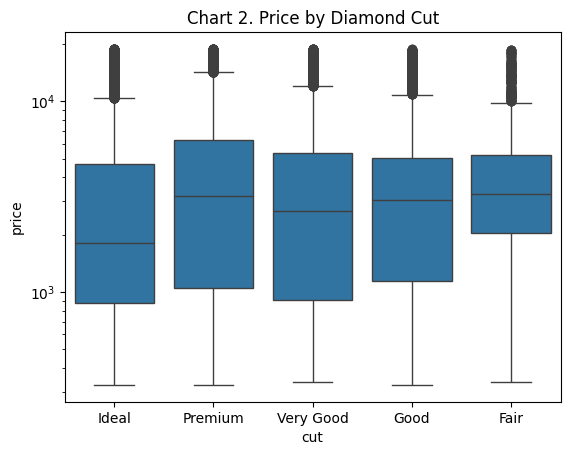

In [54]:
LOG.info("------- Creating another chart -------")
# plt.figure() opens a fresh blank canvas for the next chart
# WHY: Without this, Chart 2 draws on top of Chart 1
plt.figure()

LOG.info("------ Creating Box Plot to see Distribution: ---------")
LOG.info("------   Use clean dataframe --------------------------")
LOG.info("------   Set x to cut ---------------------------------")
LOG.info("------   Set y to price ($) ---------------------------")

# Box plot to compare distribution across species
box_plt = sns.boxplot(
    data=df_clean,
    x=GROUP_COL,
    y="price",
)
box_plt.set_yscale("log")
box_plt.set_title("Chart 2. Price by Diamond Cut")

plt.show()

## Section 9. Summary and Next Steps

At the end, of your notebook, provide:

-  brief summary of your findings 
-  suggested next steps

WHY: EDA is not a final report.
The summary of your data exploration captures you found 
and what you would like to investigate next.

This summary is in code because it is instructional - your summary
will typically be in Markdown as it is good for narrative. 

This is a Markdown cell.


In [55]:
# Section 9 Python cell

LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}")

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Clean rows:    {df_clean.shape[0]}")

# Get the unique values in the grouping column (e.g. species names)
unique_groups_array: np.ndarray = df_clean[GROUP_COL].unique()

# Sort them alphabetically so the output is consistent and readable
sorted_groups: list[str] = sorted(unique_groups_array)

LOG.info(f"Groups found in {GROUP_COL}: {sorted_groups}")

LOG.info("Strongest correlation: ")
LOG.info("  x (length of diamond) and carat (~0.98)")

LOG.info("Suggested next step: ")
LOG.info("  Model price ~ carat using linear regression")

LOG.info("EDA workflow complete")
LOG.info("IMPORTANT: This script creates chart windows.")
LOG.info("Close any chart windows and terminate this process with CTRL+c as needed.")
LOG.info("========================")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-06-03 13:39:01 | INFO | EDA-NB | ========================
2026-06-03 13:39:01 | INFO | EDA-NB | SUMMARY


2026-06-03 13:39:01 | INFO | EDA-NB | ========================
2026-06-03 13:39:01 | INFO | EDA-NB | Dataset: diamonds
2026-06-03 13:39:01 | INFO | EDA-NB | Original rows: 53940
2026-06-03 13:39:01 | INFO | EDA-NB | Clean rows:    53940
2026-06-03 13:39:01 | INFO | EDA-NB | Groups found in cut: ['Fair', 'Good', 'Ideal', 'Premium', 'Very Good']
2026-06-03 13:39:01 | INFO | EDA-NB | Strongest correlation: 
2026-06-03 13:39:01 | INFO | EDA-NB |   x (length of diamond) and carat (~0.98)
2026-06-03 13:39:01 | INFO | EDA-NB | Suggested next step: 
2026-06-03 13:39:01 | INFO | EDA-NB |   Model price ~ carat using linear regression
2026-06-03 13:39:01 | INFO | EDA-NB | EDA workflow complete
2026-06-03 13:39:01 | INFO | EDA-NB | IMPORTANT: This script creates chart windows.
2026-06-03 13:39:01 | INFO | EDA-NB | Close any chart windows and terminate this process with CTRL+c as needed.
2026-06-03 13:39:01 | INFO | EDA-NB | ========================
2026-06-03 13:39:01 | INFO | EDA-NB | Executed su

## Reminder: Run All before sending to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook. 

This is a Markdown cell.
